In [1]:
import numpy as np

In [2]:
import corner

In [3]:
catname_list = [
    'tomo_0.1-0.4',
    'tomo_0.4-0.6',
    'tomo_0.6-0.8',
    'tomo_0.8-1.0',
    'tomo_1.0-1.3',
    'tomo_1.3-1.6',
    'tomo_1.6-3.2'
]
len(catname_list)

7

In [59]:
def get_mean_std_nested(samples:dict):
    points = samples['points']
    weights = samples['weights']#[:,np.newaxis]
    loglike = samples['loglike']#[:,np.newaxis]

    # ### Bayes evidence, Z
    # bayes_Z = np.sum(np.exp(loglike)*weights, axis=0)
    # ### mean, <theta>
    # theta_means = np.sum(np.exp(loglike)*weights*points, axis=0)/bayes_Z
    # ### second-order original momentum, <theta^2>
    # theta_sq_means = np.sum(np.exp(loglike)*weights*points**2, axis=0)/bayes_Z
    # ### variance, <theta^2> - <theta>^2
    # variance = theta_sq_means - theta_means**2
    # ### std
    # std = np.sqrt(variance)
    theta_means = np.average(points, axis=0, weights=weights)
    variance = np.average((points - theta_means)**2, axis=0, weights=weights)
    std = np.sqrt(variance)

    return theta_means, std

In [60]:
sample_dict = {}
bestfit_A_IA = []
onesig_A_IA = []
bestfit_gmag = []
onesig_gmag = []
for i, catname in enumerate(catname_list):
    f = np.load(f"results/samples/{catname}_samples.npz")
    sample_dict[catname] = {}
    sample_dict[catname]['points'] = f['points']
    sample_dict[catname]['weights'] = f['weights']
    sample_dict[catname]['loglike'] = f['loglike']
    bestfit_vals, onesig_vals = get_mean_std_nested(sample_dict[catname])
    bestfit_A_IA.append(bestfit_vals[1])
    onesig_A_IA.append(onesig_vals[1])
    bestfit_gmag.append(bestfit_vals[2])
    onesig_gmag.append(onesig_vals[2])

In [10]:
from matplotlib import pyplot as plt

In [61]:
get_mean_std_nested(sample_dict[catname_list[-2]])

(array([ 2.15162406,  0.00505295, -3.09811163]),
 array([0.17190995, 0.43218118, 0.39936244]))

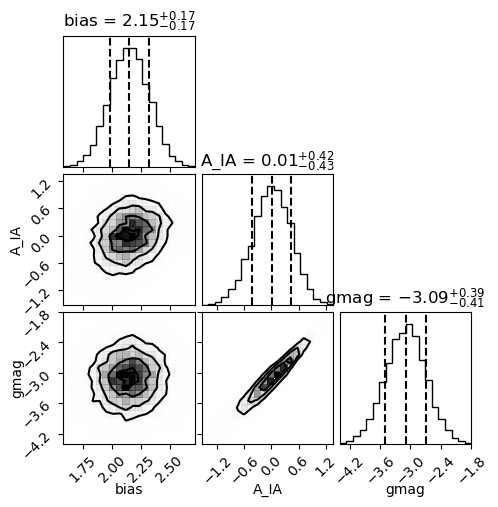

In [43]:
points = sample_dict[catname_list[-2]]['points']
weights = sample_dict[catname_list[-2]]['weights']
fig = plt.figure(figsize=(5,5),dpi=100)
corner.corner(
    points, weights=weights, bins=20, labels=['bias', 'A_IA', 'gmag'],
    plot_datapoints=False, range=np.repeat(0.999, 3),quantiles=[0.16, 0.5, 0.84],show_titles=True,
    fig=fig
);

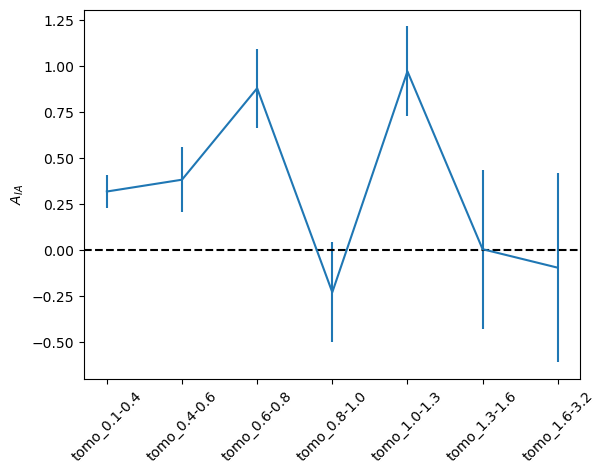

In [62]:
plt.errorbar(np.arange(7), bestfit_A_IA, onesig_A_IA)
plt.ylabel(r'$A_{IA}$')
plt.axhline(0, c='k', ls='--')
plt.xticks(np.arange(7), catname_list, rotation=45);

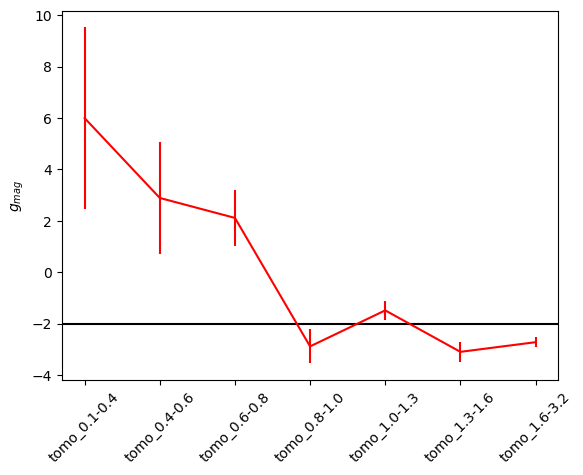

In [63]:
plt.errorbar(np.arange(7), bestfit_gmag, onesig_gmag, c='r')
plt.ylabel(r'$g_{mag}$')
plt.axhline(-2, c='k', ls='-')
plt.xticks(np.arange(7), catname_list, rotation=45);